Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pyreadr

Loading Datasets

In [2]:
import os

# 1. Define the folder path using a raw string
base_path = r"C:\Users\khush\Downloads\anamoly"

files = {
    "train_nonfaulty": "TEP_FaultFree_Training.RData",    
    "test_nonfaulty": "TEP_FaultFree_Testing.RData",
}

df = {}

for key, filename in files.items():  
    full_path = os.path.join(base_path, filename)
    try:        # load the RData file        
        result = pyreadr.read_r(full_path) # The result is a dictionary where the key is usually the internal R variable name and the first object available  is our df.        
        df_name = list(result.keys())[0]        
        df[key] = result[df_name]                
        print(f"loaded {key}: {df[key].shape}")
    except FileNotFoundError:        
        print(f"Error: {filename}.") 
        
df_train_nonfaulty = df.get("train_nonfaulty") 
df_test_nonfaulty = df.get("test_nonfaulty")

loaded train_nonfaulty: (250000, 55)
loaded test_nonfaulty: (480000, 55)


In [3]:
import gc

base_path = r"C:\Users\khush\Downloads\anamoly"
files = {
    "train_faulty": "TEP_Faulty_Training.RData",
    "test_faulty": "TEP_Faulty_Testing.RData"
}

# 1. Process each file one-by-one to save RAM
# Processing them together in a loop and storing them in a dict 'df' 
# will use ~8-10GB of RAM, exceeding your 7.3GB limit

# --- Handle Training ---
result = pyreadr.read_r(os.path.join(base_path, files["train_faulty"]))
obj = list(result.keys())[0]
# Filter for Fault 20 immediately and downcast to float32
train_fault_20 = result[obj][result[obj]['faultNumber'] == 20].copy().astype('float32')
del result
gc.collect()

# --- Handle Testing ---
result = pyreadr.read_r(os.path.join(base_path, files["test_faulty"]))
obj = list(result.keys())[0]
# Filter for Fault 20 immediately
test_fault_20 = result[obj][result[obj]['faultNumber'] == 20].copy().astype('float32')
del result
gc.collect()

print(f"Success! Fault 20 Training Rows: {len(train_fault_20)}")
print(f"Success! Fault 20 Testing Rows: {len(test_fault_20)}")

Success! Fault 20 Training Rows: 250000
Success! Fault 20 Testing Rows: 480000


Handling Outliers

In [4]:
def cap_outliers_percentile(df, column_list, lower_q=0.025, upper_q=0.975):
    """
    Caps extreme values at the 2.5% and 97.5% marks instead of deleting rows.
    Retains 100% of the dataset.
    """
    capped_df = df.copy()
    
    for col in column_list:
        if col.startswith(('xmeas', 'xmv')):
            # Calculate the thresholds (5% total "trim" per column)
            lower_bound = df[col].quantile(lower_q)
            upper_bound = df[col].quantile(upper_q)
            
            # Clip limits the values to exactly these boundaries
            capped_df[col] = capped_df[col].clip(lower=lower_bound, upper=upper_bound)
            
    return capped_df

# 1. Apply capping ONLY to the Non-Faulty training data
print(f"Original Normal Rows: {len(df_train_nonfaulty)}")
train_nonfaulty_clean = cap_outliers_percentile(df_train_nonfaulty, df_train_nonfaulty.columns)
print(f"Cleaned Normal Rows: {len(train_nonfaulty_clean)}") # This will be the exact same number!

# 2. Free up memory
del df_train_nonfaulty
gc.collect()

print("Capping complete! 0 rows lost.")

Original Normal Rows: 250000


Cleaned Normal Rows: 250000
Capping complete! 0 rows lost.


In [5]:
print(f"Original Normal Rows: {len(df_test_nonfaulty)}")
test_nonfaulty_clean = cap_outliers_percentile(df_test_nonfaulty, df_test_nonfaulty.columns)
print(f"Cleaned Normal Rows: {len(test_nonfaulty_clean)}")

# 3. Free up memory
del df_test_nonfaulty
gc.collect()

Original Normal Rows: 480000
Cleaned Normal Rows: 480000


0

In [6]:
print(f"Original Normal Rows: {len(train_fault_20)}")
train_fault20_clean = cap_outliers_percentile(train_fault_20, train_fault_20.columns)
print(f"Cleaned Normal Rows: {len(train_fault20_clean)}")

# 3. Free up memory
del train_fault_20
gc.collect()

Original Normal Rows: 250000
Cleaned Normal Rows: 250000


0

In [7]:
print(f"Original Normal Rows: {len(test_fault_20)}")
test_fault20_clean = cap_outliers_percentile(test_fault_20, test_fault_20.columns)
print(f"Cleaned Normal Rows: {len(test_fault20_clean)}")

# 3. Free up memory
del test_fault_20
gc.collect()

Original Normal Rows: 480000
Cleaned Normal Rows: 480000


0

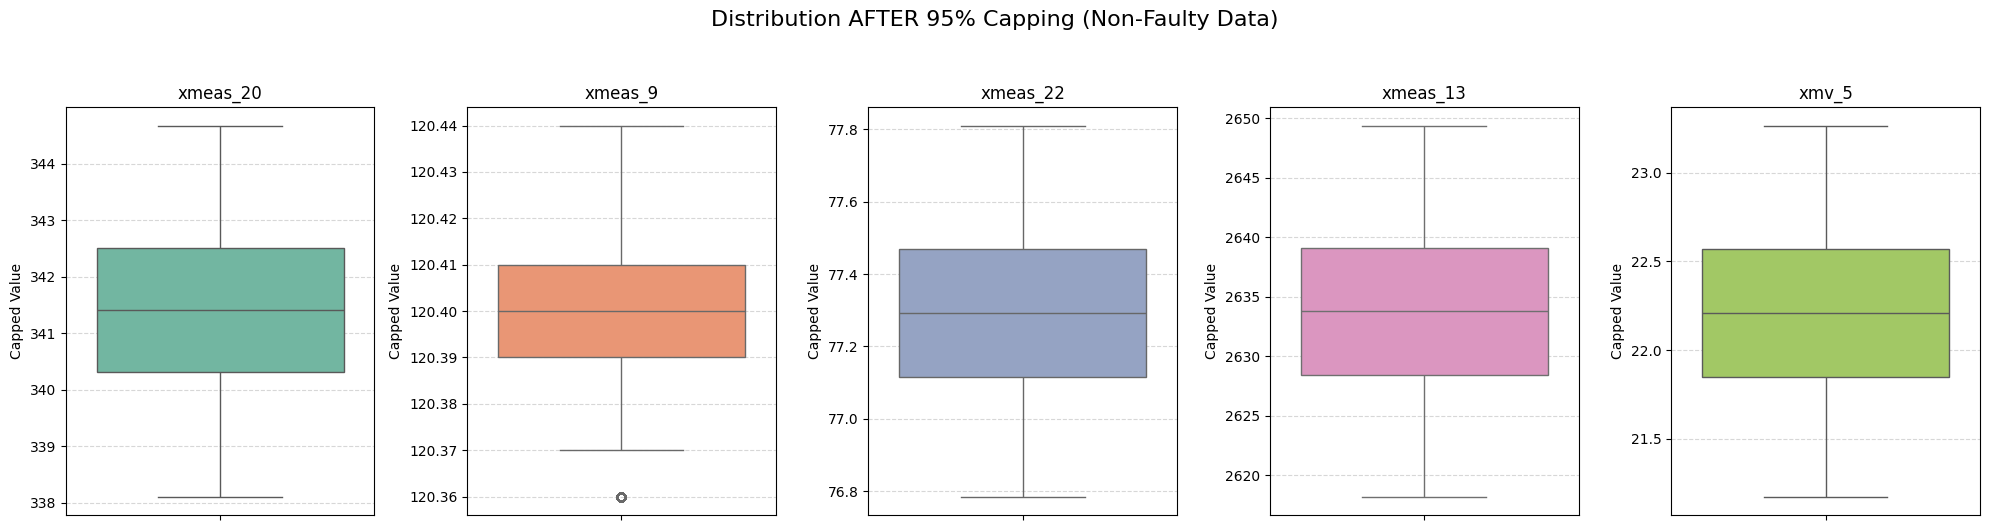

In [22]:
# 1. Select the top 5 volatile sensors (added xmv_5 to make it 5)
sensors_to_check = ['xmeas_20', 'xmeas_9', 'xmeas_22', 'xmeas_13', 'xmv_5']

# 2. Take a memory-safe sample (keeps your RAM usage low)
sample_clean = train_nonfaulty_clean[sensors_to_check].iloc[:50000]

# 3. Create a grid of subplots (1 row, 5 columns)
# figsize=(20, 5) makes it wide enough so the plots don't squish together
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 5))

# 4. Loop through each sensor and plot it on its own designated axis
for i, sensor in enumerate(sensors_to_check):
    # sns.boxplot needs to know which column of the data to use (y) and which axis to draw on (ax)
    sns.boxplot(y=sample_clean[sensor], ax=axes[i], color=sns.color_palette("Set2")[i])
    
    # Customize each individual plot
    axes[i].set_title(f"{sensor}", fontsize=12)
    axes[i].set_ylabel("Capped Value")
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# 5. Adjust layout so titles and labels don't overlap, then show
plt.suptitle("Distribution AFTER 95% Capping (Non-Faulty Data)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [16]:
from sklearn.preprocessing import StandardScaler

# Define the sensor columns you want to scale (exclude labels/IDs)
features = [col for col in train_nonfaulty_clean.columns if col.startswith(('xmeas', 'xmv'))]

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. FIT and TRANSFORM on the Cleaned Normal Data
# This calculates the mean/std of a perfectly healthy plant
train_nonfaulty_scaled = train_nonfaulty_clean.copy()
train_nonfaulty_scaled[features] = scaler.fit_transform(train_nonfaulty_clean[features])

# 3. ONLY TRANSFORM on the Faulty Data
# We do NOT fit again. We apply the normal plant's math to the fault.
train_fault_scaled = train_fault20_clean.copy()
train_fault_scaled[features] = scaler.transform(train_fault20_clean[features])

# 4. NOW we Merge them into our final Training Set!
final_train_df = pd.concat([train_nonfaulty_scaled, train_fault_scaled], axis=0).reset_index(drop=True)

# 5. RAM Clean-up (Critical for your 8GB system)
del train_nonfaulty_scaled
del train_fault_scaled
gc.collect()

print(f"Scaling and Merge Complete! Final Training Rows: {len(final_train_df)}")

Scaling and Merge Complete! Final Training Rows: 500000


In [17]:
from sklearn.preprocessing import StandardScaler

# Define the sensor columns you want to scale (exclude labels/IDs)
features = [col for col in test_nonfaulty_clean.columns if col.startswith(('xmeas', 'xmv'))]

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. FIT and TRANSFORM on the Cleaned Normal Data
# This calculates the mean/std of a perfectly healthy plant
test_nonfaulty_scaled = test_nonfaulty_clean.copy()
test_nonfaulty_scaled[features] = scaler.fit_transform(test_nonfaulty_clean[features])

# 3. ONLY TRANSFORM on the Faulty Data
# We do NOT fit again. We apply the normal plant's math to the fault.
test_fault_scaled = test_fault20_clean.copy()
test_fault_scaled[features] = scaler.transform(test_fault20_clean[features])

# 4. NOW we Merge them into our final testing Set!
final_test_df = pd.concat([test_nonfaulty_scaled, test_fault_scaled], axis=0).reset_index(drop=True)

# 5. RAM Clean-up (Critical for your 8GB system)
del test_nonfaulty_scaled
del test_fault_scaled
gc.collect()

print(f"Scaling and Merge Complete! Final testing Rows: {len(final_test_df)}")

Scaling and Merge Complete! Final testing Rows: 960000


Training Random Forest to extract importance...


C:\Users\khush\AppData\Local\Temp\ipykernel_25924\876318034.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')


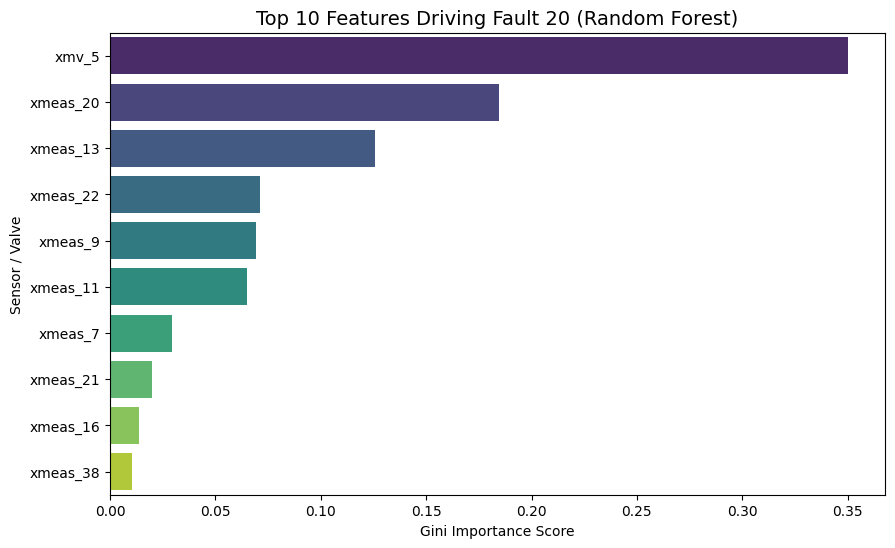

Top 5 Features:
      Feature  Importance
45     xmv_5    0.350231
19  xmeas_20    0.184411
12  xmeas_13    0.125664
21  xmeas_22    0.071053
8    xmeas_9    0.069330


In [18]:
from sklearn.ensemble import RandomForestClassifier

# 1. Define X (Features) and y (Target Labels)
# We convert the target to a simple Binary format: 0 (Normal) and 1 (Fault 20)
X_train = final_train_df[features].astype('float32') 
y_train = final_train_df['faultNumber'].apply(lambda x: 1 if x == 20 else 0).astype('int8')

# 2. Initialize and Train a Lightweight Random Forest
# n_jobs=-1 uses all your CPU cores to finish faster
print("Training Random Forest to extract importance...")
rf_model = RandomForestClassifier(n_estimators=25, max_depth=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 3. Extract the Importance Scores
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. Visualize the Top 10 Features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title("Top 10 Features Driving Fault 20 (Random Forest)", fontsize=14)
plt.xlabel("Gini Importance Score")
plt.ylabel("Sensor / Valve")
plt.show()

# 5. RAM Clean-up 
del rf_model
gc.collect()
print("Top 5 Features:\n", importance_df.head(5))

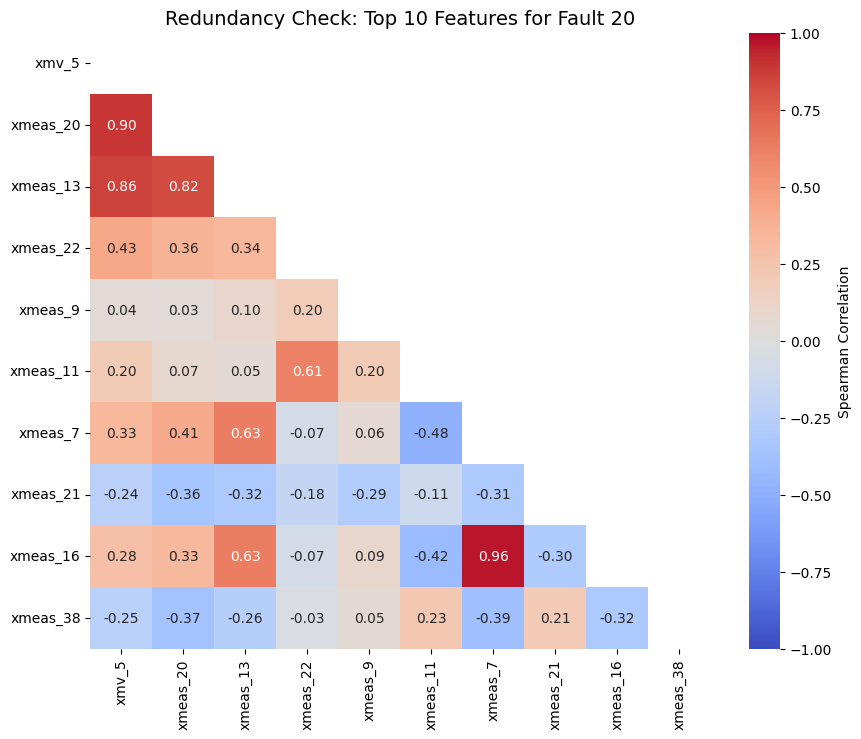

In [19]:
# 1. Extract just the names of your Top 10 features
top_10_features = importance_df['Feature'].head(10).tolist()

# 2. Calculate Spearman correlation ONLY on these 10 columns
# We use X_train since it's already properly scaled and merged
corr_matrix = X_train[top_10_features].corr(method='spearman')

# 3. Create a mask to hide the upper triangle (makes it look much cleaner)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Plot the zoomed-in Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            cbar_kws={'label': 'Spearman Correlation'}, vmin=-1, vmax=1)
plt.title("Redundancy Check: Top 10 Features for Fault 20", fontsize=14)
plt.show()

In [20]:
# 1. Define your curated list of final features
final_features = [
    'xmv_5', 
    'xmeas_22', 
    'xmeas_9', 
    'xmeas_11', 
    'xmeas_7', 
    'xmeas_21', 
    'xmeas_38'
]

X_test = final_test_df[features].astype('float32') 
y_test = final_test_df['faultNumber'].apply(lambda x: 1 if x == 20 else 0).astype('int8')

# 2. Slice the training data to ONLY include these 7 columns
# Using .copy() ensures we aren't just making a memory-heavy reference
X_train_final = X_train[final_features].copy()
X_test_final = X_test[final_features].copy()

print(f"Data perfectly optimized! Final Training Shape: {X_train_final.shape}")
print(f"Data perfectly optimized! Final Testing Shape: {X_test_final.shape}")

Data perfectly optimized! Final Training Shape: (500000, 7)
Data perfectly optimized! Final Testing Shape: (960000, 7)


Training Anomaly Detection model...
Training complete!


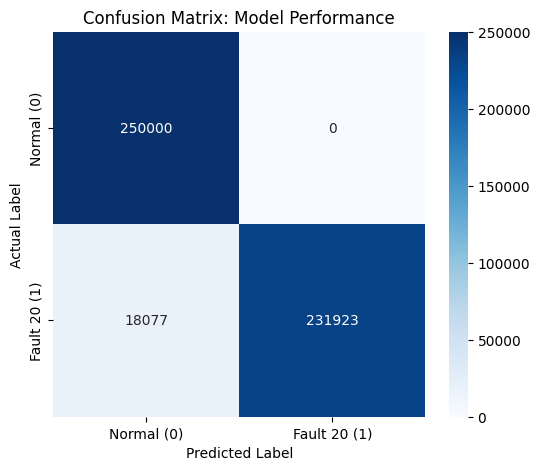


Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      1.00      0.97    250000
    Fault 20       1.00      0.93      0.96    250000

    accuracy                           0.96    500000
   macro avg       0.97      0.96      0.96    500000
weighted avg       0.97      0.96      0.96    500000



In [21]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the Model
# n_estimators=50 and max_depth=10 keep memory usage low while maintaining accuracy
# class_weight='balanced' adjusts for the fact that you have more Normal data than Fault 20 data
rf_model = RandomForestClassifier(
    n_estimators=50, 
    max_depth=10, 
    random_state=42, 
    n_jobs=-1, 
    class_weight='balanced'
)

# 2. Train the Model
print("Training Anomaly Detection model...")
rf_model.fit(X_train_final, y_train)
print("Training complete!")

# 3. Generate Predictions (Checking performance on the training data)
y_pred = rf_model.predict(X_train_final)

# 4. Visualize Performance with a Confusion Matrix
cm = confusion_matrix(y_train, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Fault 20 (1)'], 
            yticklabels=['Normal (0)', 'Fault 20 (1)'])
plt.title("Confusion Matrix: Model Performance")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

# 5. Print Detailed Metrics
print("\nClassification Report:")
print(classification_report(y_train, y_pred, target_names=['Normal', 'Fault 20']))